In [1]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


Task 1: Data Preparation

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification.

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [3]:
def load_data(data_dir):
    images = []
    labels = []

    class_names = sorted(os.listdir(data_dir))

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        # Extract label (digit_3 → 3)
        label = int(class_name.split('_')[1])

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            try:
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize((28, 28))
                img = np.array(img) / 255.0  # normalize

                images.append(img)
                labels.append(label)
            except:
                pass

    return np.array(images), np.array(labels)

In [4]:
base_path = "/content/drive/MyDrive/AI and Machine Learning/WEEK4/DevanagariHandwrittenDigitDataset"
X_train, y_train = load_data(os.path.join(base_path, "Train"))
X_test, y_test = load_data(os.path.join(base_path, "Test"))

print("Before reshape:")
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

Before reshape:
(17000, 28, 28) (17000,)
(3000, 28, 28) (3000,)


In [5]:
# Keep as 28x28 (Flatten later in model)
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

# One-hot encode
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("After processing:")
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

After processing:
(17000, 28, 28) (17000, 10)
(3000, 28, 28) (3000, 10)


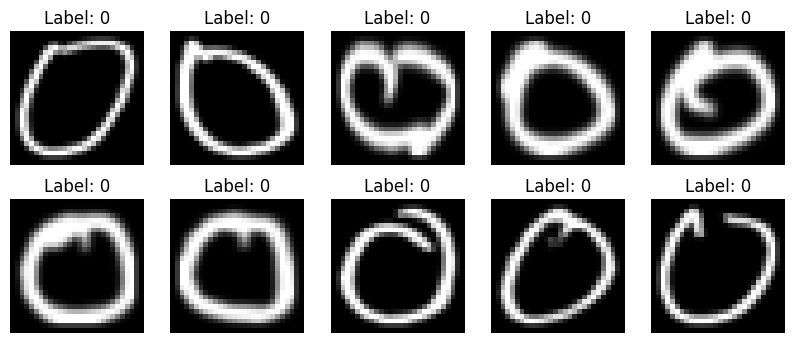

In [6]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.show()

Task 2: Build the FCN Model

Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a softmax activation function.

In [7]:
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(64, activation='sigmoid'))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(256, activation='sigmoid'))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [9]:
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2481 - loss: 2.0295

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4651 - loss: 1.6521 - val_accuracy: 0.0000e+00 - val_loss: 7.0208
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8325 - loss: 0.5183 - val_accuracy: 0.0000e+00 - val_loss: 8.3908
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9070 - loss: 0.2913 - val_accuracy: 0.0000e+00 - val_loss: 8.8445
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9449 - loss: 0.1969 - val_accuracy: 0.0000e+00 - val_loss: 9.4087
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9580 - loss: 0.1476 - val_accuracy: 0.0000e+00 - val_loss: 9.7739
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9650 - loss: 0.1205 - val_accuracy: 0.0000e+00 - val_loss: 10.0716


Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.

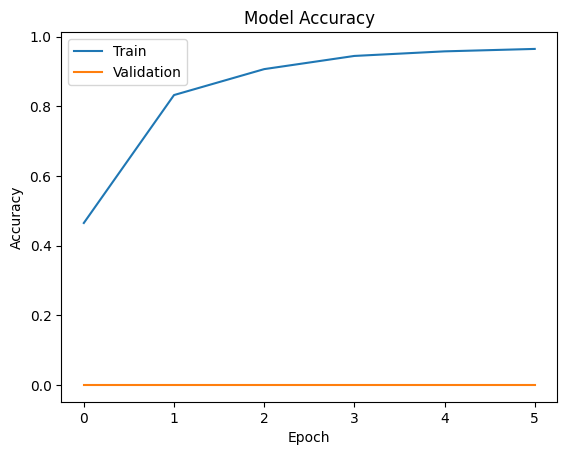

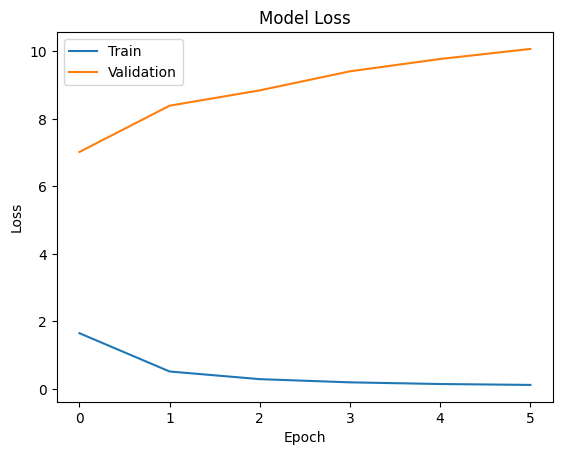

In [10]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6220 - loss: 2.0568
Test Accuracy: 0.621999979019165
Test Loss: 2.056842565536499


Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set

In [12]:
# Save
model.save("devnagari_fcn.h5")

# Load
loaded_model = load_model("devnagari_fcn.h5")

# Re-evaluate
loss, accuracy = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6220 - loss: 2.0568
Loaded Model Accuracy: 0.621999979019165


In [ ]:
Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


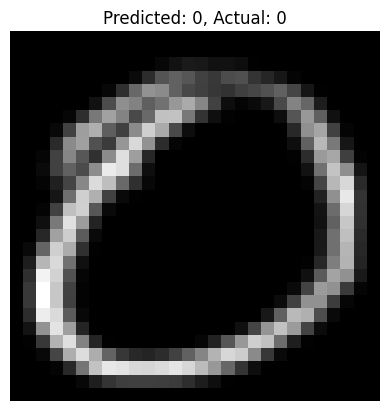

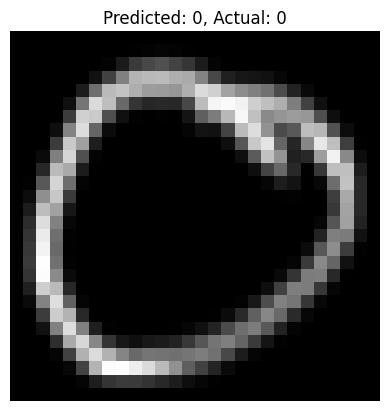

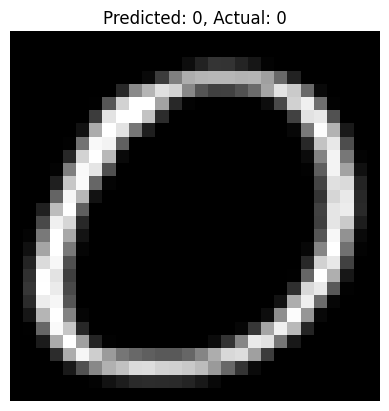

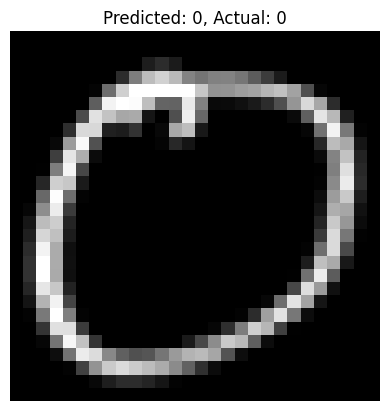

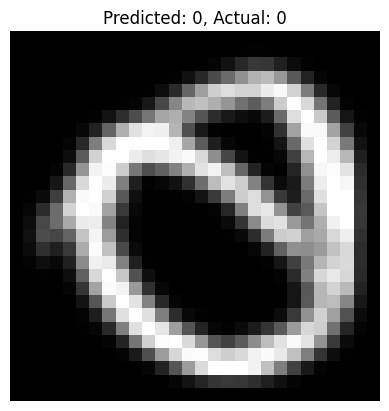

In [13]:
predictions = loaded_model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Show predictions
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}, Actual: {true_labels[i]}")
    plt.axis('off')
    plt.show()